# Study 16 — How large must an ability change be before we can reliably find it?

## Question

Study 15 showed that a genuine permanent improvement can leave a statistical signal without making its location reliably identifiable.

A player improved from a true frame-win probability of **58% to 64%** halfway through a 5,000-frame career. We searched the entire career using the same simple before-versus-after comparison at every possible location.

The real change made the correct region much more likely to stand out than chance alone would suggest. But the strongest-looking change still fell within ±250 frames of the true change point in only **38.29%** of simulated careers.

Why?

One possibility is that searching an entire career creates so many opportunities for random variation that this detector is fundamentally unreliable.

Another is simpler:

**perhaps a six-percentage-point change is just not large enough to consistently dominate the random peaks created elsewhere in a noisy career.**

This study separates those possibilities.

We will keep the Study 15 world unchanged and vary only one thing:

> **the size of the permanent ability change.**

The simulated player will again have:

- a 5,000-frame career;
- an initial true frame-win probability of **58%**;
- a permanent change after frame **2,500**;
- independent frames;
- no momentum;
- no opponent effects;
- no parameter uncertainty.

We will use the same detector:

- compare the preceding 250 frames with the following 250 frames;
- calculate the increase in wins after each candidate point;
- search every possible location;
- retain the strongest apparent improvement.

We will also keep the same definition of successful localisation:

> **the selected point must fall within ±250 frames of the true change.**

The only quantity we will vary is the player's post-change frame-win probability.

The central question is:

> **How strong does a genuine permanent improvement need to be before it consistently beats the random peaks created by searching the rest of the career?**

We are not trying to improve the detector yet.

First we need to understand how the strength of the underlying signal changes what the existing detector can see.

## Experimental design

Study 15 examined one permanent improvement:

**58% → 64%**

Here we will repeat the same hidden-change search across several possible post-change abilities.

The pre-change probability will remain fixed at **58%**.

We will test:

| Post-change probability | Change size |
|---:|---:|
| 58% | 0 percentage points |
| 60% | +2 percentage points |
| 62% | +4 percentage points |
| 64% | +6 percentage points |
| 66% | +8 percentage points |
| 68% | +10 percentage points |
| 70% | +12 percentage points |

The **58% → 58%** case is the no-change control.

For every other condition, the change will occur after frame **2,500**.

Nothing else changes between experiments.

For each change size we will measure:

1. **localisation accuracy** — how often the strongest apparent improvement falls within ±250 frames of the true change;
2. **location error** — the mean and median absolute distance between the selected point and frame 2,500;
3. **signal versus background** — how often the strongest contrast near the genuine change beats the strongest contrast elsewhere in the career;
4. **search-adjusted detection** — how often the career exceeds a whole-career false-alarm threshold derived from the no-change control.

This gives us a controlled signal-strength experiment.

If localisation improves steadily as the true change becomes larger, Study 15's difficulty was not simply a defective detector. It was partly a consequence of trying to recover a modest signal from thousands of noisy alternatives.

If even very large changes remain difficult to locate, that would point instead to a more fundamental limitation of the detector itself.

In [1]:
# Import the libraries used throughout the study.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep the simulated career identical to Study 15:
# 5,000 frames with the genuine change occurring halfway through.
career_length = 5_000
change_point = 2_500

# The player's initial underlying frame-win probability stays fixed at 58%.
pre_change_p = 0.58

# Vary only the size of the permanent post-change improvement.
# The first value is the no-change control.
post_change_probabilities = np.array([
    0.58,
    0.60,
    0.62,
    0.64,
    0.66,
    0.68,
    0.70,
])

# Use the same detector as Study 15:
# compare the 250 frames before each candidate point with the 250 after it.
window_size = 250

# A detected location counts as successful if it falls within
# 250 frames either side of the true change point.
localisation_tolerance = 250

# Repeat each experimental condition across many simulated careers
# so that the comparison between change sizes is stable.
n_simulations = 10_000

# Display the main experimental settings as a quick check.
career_length, change_point, pre_change_p, post_change_probabilities

(5000, 2500, 0.58, array([0.58, 0.6 , 0.62, 0.64, 0.66, 0.68, 0.7 ]))

## Reusing the Study 15 detector

To isolate the effect of **change size**, the detector itself must remain unchanged.

At every possible candidate point, we will compare:

- wins in the preceding 250 frames;
- wins in the following 250 frames.

The search statistic is:

$$
\text{increase}
=
\text{wins after}
-
\text{wins before}
$$

The detector will then search the whole career and retain the candidate point with the largest apparent improvement.

This is deliberately simple.

We are not trying to design a better change-point method in this study. We are asking how the **same imperfect detector** behaves as the genuine underlying signal becomes stronger.

That distinction matters.

If performance improves as the true ability change gets larger, then the poor localisation seen in Study 15 was at least partly a **signal-to-noise problem**, rather than evidence that whole-career search is completely uninformative.

In [2]:
# Recreate the Study 15 whole-career detector as a reusable function.
def find_strongest_improvement(frames, window_size=250):
    """
    Search a binary win/loss career for the strongest apparent improvement.

    At every valid candidate point, compare wins in the preceding window
    with wins in the following window, then retain the largest increase.
    """

    # Convert the input to a NumPy array so the calculations below
    # behave consistently even if another array-like object is supplied.
    frames = np.asarray(frames)

    # Cumulative wins let us calculate every 250-frame window total
    # without repeatedly summing slices of the career.
    cumulative_wins = np.concatenate(([0], np.cumsum(frames)))

    # A candidate point needs a complete window on both sides.
    # For a 5,000-frame career and 250-frame windows this produces
    # candidate points 250 through 4,750 inclusive.
    candidate_points = np.arange(
        window_size,
        len(frames) - window_size + 1
    )

    # Count wins in the window immediately before each candidate point.
    wins_before = (
        cumulative_wins[candidate_points]
        - cumulative_wins[candidate_points - window_size]
    )

    # Count wins in the window immediately after each candidate point.
    wins_after = (
        cumulative_wins[candidate_points + window_size]
        - cumulative_wins[candidate_points]
    )

    # Positive values represent an apparent improvement after the point.
    increases = wins_after - wins_before

    # Retain the location with the largest apparent increase.
    strongest_index = np.argmax(increases)

    strongest_point = candidate_points[strongest_index]
    strongest_increase = increases[strongest_index]

    # Return both the winning result and the full search surface.
    # We will need the full set of contrasts later when comparing
    # the genuine-change region with the background.
    return {
        "strongest_point": strongest_point,
        "strongest_increase": strongest_increase,
        "candidate_points": candidate_points,
        "increases": increases,
    }

In [3]:
# Create a dummy 5,000-frame career purely to inspect the search geometry.
# The actual win/loss values do not matter for this check.
dummy_frames = np.zeros(career_length, dtype=int)

# Run the detector once so we can inspect the candidate locations.
dummy_result = find_strongest_improvement(
    dummy_frames,
    window_size=window_size
)

# Confirm the first and last valid candidate points,
# together with the total number of locations searched.
(
    dummy_result["candidate_points"][0],
    dummy_result["candidate_points"][-1],
    len(dummy_result["candidate_points"]),
)

(np.int64(250), np.int64(4750), 4501)

## Detector validation

The reusable detector reproduces the illustrative Study 15 result exactly.

Using the same simulated **58% → 64%** career, it identifies:

- the strongest apparent change after frame **2,540**;
- a maximum before-versus-after contrast of **+35 wins**.

Study 15 found the same location and the same contrast.

This is an important check.

Study 16 is intended to vary only the **size of the genuine ability change**. If the detector had changed as well, we would no longer know whether differences in performance were caused by a stronger signal or by a different search method.

We can therefore proceed knowing that the detector itself has remained fixed.

In [4]:
# Simulate one complete career for a chosen post-change probability
# and apply the unchanged Study 15 detector to it.
def simulate_hidden_change_career(
    rng,
    post_change_p,
    pre_change_p=0.58,
    career_length=5_000,
    change_point=2_500,
    window_size=250,
    localisation_tolerance=250,
):
    """
    Simulate one career containing a permanent ability change and measure
    how well the whole-career detector identifies it.
    """

    # Construct the player's true frame-win probability across the career.
    # Every frame before the change point uses the fixed 58% baseline.
    true_probabilities = np.full(career_length, pre_change_p)

    # From the change point onward, replace the baseline probability
    # with the post-change probability being tested.
    true_probabilities[change_point:] = post_change_p

    # Generate the observed sequence of frame results.
    # 1 represents a frame win and 0 represents a frame loss.
    frames = rng.binomial(1, true_probabilities)

    # Search the entire career using exactly the same detector
    # that we validated against Study 15.
    detector_result = find_strongest_improvement(
        frames,
        window_size=window_size
    )

    strongest_point = detector_result["strongest_point"]
    strongest_increase = detector_result["strongest_increase"]

    candidate_points = detector_result["candidate_points"]
    increases = detector_result["increases"]

    # Measure how far the selected location lies from the genuine
    # change point placed at frame 2,500.
    absolute_location_error = abs(
        strongest_point - change_point
    )

    # Apply the same ±250-frame localisation criterion as Study 15.
    correctly_located = (
        absolute_location_error <= localisation_tolerance
    )

    # Define the genuine-change region as all candidate points
    # within ±250 frames of the true change point.
    signal_region = (
        np.abs(candidate_points - change_point)
        <= localisation_tolerance
    )

    # Everything outside that region forms the background search space.
    background_region = ~signal_region

    # Find the strongest apparent improvement inside the region
    # containing the genuine change.
    best_signal_increase = increases[signal_region].max()

    # Find the strongest apparent improvement anywhere else
    # in the career.
    best_background_increase = increases[background_region].max()

    # Return the quantities needed for the repeated experiment later.
    return {
        "post_change_p": post_change_p,
        "strongest_point": strongest_point,
        "strongest_increase": strongest_increase,
        "absolute_location_error": absolute_location_error,
        "correctly_located": correctly_located,
        "best_signal_increase": best_signal_increase,
        "best_background_increase": best_background_increase,
    }

In [5]:
# Use a fresh reproducible random generator for this one-career test.
test_rng = np.random.default_rng(1601)

# Simulate one career with the same 58% -> 64% change used in Study 15.
test_result = simulate_hidden_change_career(
    rng=test_rng,
    post_change_p=0.64,
)

# Display the complete result so we can check that every quantity
# needed for the repeated experiment is being produced correctly.
test_result

{'post_change_p': 0.64,
 'strongest_point': np.int64(2077),
 'strongest_increase': np.int64(25),
 'absolute_location_error': np.int64(423),
 'correctly_located': np.False_,
 'best_signal_increase': np.int64(25),
 'best_background_increase': np.int64(25)}

In [6]:
# Reproduce the 10,000-career 58% -> 64% experiment from Study 15.
# This is a regression test before we introduce any new change sizes.
study15_validation_rng = np.random.default_rng(1501)

study15_validation_results = []

# Run the unchanged whole-career search across 10,000 simulated careers.
for _ in range(n_simulations):
    result = simulate_hidden_change_career(
        rng=study15_validation_rng,
        post_change_p=0.64,
    )

    study15_validation_results.append(result)

# Convert the individual career results into a DataFrame so that
# the repeated-simulation behaviour is easy to summarise.
study15_validation_df = pd.DataFrame(
    study15_validation_results
)

# Measure how often the selected location falls within ±250 frames
# of the genuine change point.
localisation_rate = (
    study15_validation_df["correctly_located"].mean()
)

# Summarise the absolute distance between the selected point
# and the genuine change after frame 2,500.
median_location_error = (
    study15_validation_df["absolute_location_error"].median()
)

mean_location_error = (
    study15_validation_df["absolute_location_error"].mean()
)

# Summarise the size of the strongest apparent improvement
# selected anywhere in each career.
median_strongest_increase = (
    study15_validation_df["strongest_increase"].median()
)

mean_strongest_increase = (
    study15_validation_df["strongest_increase"].mean()
)

# Compare the strongest contrast near the genuine change
# with the strongest contrast in the rest of the career.
signal_stronger = (
    study15_validation_df["best_signal_increase"]
    > study15_validation_df["best_background_increase"]
).mean()

background_stronger = (
    study15_validation_df["best_background_increase"]
    > study15_validation_df["best_signal_increase"]
).mean()

signal_background_tie = (
    study15_validation_df["best_signal_increase"]
    == study15_validation_df["best_background_increase"]
).mean()

# Display the regression-test summary.
print(f"Correctly located within ±250: {localisation_rate:.2%}")
print()
print(f"Median absolute location error: {median_location_error:,.0f} frames")
print(f"Mean absolute location error: {mean_location_error:,.1f} frames")
print()
print(f"Median strongest increase: +{median_strongest_increase:,.0f} wins")
print(f"Mean strongest increase: +{mean_strongest_increase:,.2f} wins")
print()
print(f"Signal region strictly stronger: {signal_stronger:.2%}")
print(f"Background strictly stronger: {background_stronger:.2%}")
print(f"Tie: {signal_background_tie:.2%}")

Correctly located within ±250: 38.29%

Median absolute location error: 589 frames
Mean absolute location error: 792.4 frames

Median strongest increase: +31 wins
Mean strongest increase: +32.11 wins

Signal region strictly stronger: 36.69%
Background strictly stronger: 59.23%
Tie: 4.08%


## Repeated-simulation validation

The new implementation also reproduces the full repeated Study 15 experiment exactly.

Across 10,000 simulated **58% → 64%** careers:

- **38.29%** of selected locations fell within ±250 frames of the true change;
- median absolute location error was **589 frames**;
- mean absolute location error was **792.4 frames**;
- the median strongest apparent improvement was **+31 wins**;
- the mean strongest apparent improvement was **+32.11 wins**.

When the strongest contrast near the genuine change was compared with the strongest contrast elsewhere:

- genuine-change region strictly stronger: **36.69%**;
- background strictly stronger: **59.23%**;
- tie: **4.08%**.

These are exactly the results obtained in Study 15.

That gives us an important experimental baseline:

> **Any differences we observe from this point onward will come from changing the strength of the underlying ability change, not from changing the detector.**

We can now move beyond the original 58% → 64% case and ask how detection performance changes as the genuine signal becomes weaker or stronger.

In [7]:
# Give every change-size condition its own reproducible random generator.
#
# We deliberately retain the original Study 15 seeds for:
#   58% -> 58% : matched no-change control (seed 1502)
#   58% -> 64% : genuine-change experiment (seed 1501)
#
# This means those two rows can be checked directly against Study 15.
condition_seeds = {
    0.58: 1502,
    0.60: 1602,
    0.62: 1603,
    0.64: 1501,
    0.66: 1604,
    0.68: 1605,
    0.70: 1606,
}

all_condition_results = []

# Repeat the complete whole-career search 10,000 times
# for every post-change probability in the experiment.
for post_change_p in post_change_probabilities:

    # Start a separate reproducible simulation stream
    # for this particular change-size condition.
    condition_rng = np.random.default_rng(
        condition_seeds[float(post_change_p)]
    )

    for simulation in range(n_simulations):

        # Simulate one career and apply the unchanged Study 15 detector.
        result = simulate_hidden_change_career(
            rng=condition_rng,
            post_change_p=post_change_p,
        )

        # Keep the simulation number so individual careers remain
        # identifiable if we need to inspect them later.
        result["simulation"] = simulation + 1

        all_condition_results.append(result)

# Combine all 70,000 simulated careers into one table.
change_size_results = pd.DataFrame(all_condition_results)

# Add an explicit percentage-point change column for easier interpretation.
change_size_results["change_pp"] = (
    (change_size_results["post_change_p"] - pre_change_p) * 100
)

# Basic structural checks before analysing the results.
print(f"Total simulated careers: {len(change_size_results):,}")
print(
    f"Careers per condition: "
    f"{change_size_results.groupby('post_change_p').size().unique()}"
)
print(
    f"Post-change probabilities: "
    f"{sorted(change_size_results['post_change_p'].unique())}"
)

Total simulated careers: 70,000
Careers per condition: [10000]
Post-change probabilities: [np.float64(0.58), np.float64(0.6), np.float64(0.62), np.float64(0.64), np.float64(0.66), np.float64(0.68), np.float64(0.7)]


In [8]:
# Summarise localisation performance separately for each change size.
localisation_summary = (
    change_size_results
    .groupby(["post_change_p", "change_pp"])
    .agg(
        # Fraction of careers where the strongest apparent improvement
        # falls within ±250 frames of the true change point.
        localisation_rate=("correctly_located", "mean"),

        # Typical distance between the detector's selected point
        # and the genuine change after frame 2,500.
        median_location_error=("absolute_location_error", "median"),
        mean_location_error=("absolute_location_error", "mean"),

        # Typical size of the strongest apparent improvement
        # found anywhere in the career.
        median_strongest_increase=("strongest_increase", "median"),
        mean_strongest_increase=("strongest_increase", "mean"),
    )
    .reset_index()
)

# Convert the localisation rate to a percentage for easier reading.
localisation_summary["localisation_pct"] = (
    localisation_summary["localisation_rate"] * 100
)

# Arrange the columns in the order most useful for interpretation.
localisation_summary = localisation_summary[
    [
        "post_change_p",
        "change_pp",
        "localisation_pct",
        "median_location_error",
        "mean_location_error",
        "median_strongest_increase",
        "mean_strongest_increase",
    ]
]

# Display the complete change-size comparison.
localisation_summary.round(
    {
        "post_change_p": 2,
        "change_pp": 0,
        "localisation_pct": 2,
        "median_location_error": 0,
        "mean_location_error": 1,
        "median_strongest_increase": 0,
        "mean_strongest_increase": 2,
    }
)

,post_change_p,change_pp,localisation_pct,median_location_error,mean_location_error,median_strongest_increase,mean_strongest_increase
0,0.58,0.0,10.26,1134.0,1137.2,30.0,30.36
1,0.60,2.0,17.18,1048.0,1058.8,30.0,30.55
2,0.62,4.0,25.95,882.0,943.9,31.0,31.18
3,0.64,6.0,38.29,589.0,792.4,31.0,32.11
4,0.66,8.0,53.35,181.0,600.1,33.0,33.57
5,0.68,10.0,67.39,77.0,431.9,35.0,35.68
6,0.70,12.0,79.51,44.0,274.0,38.0,38.56


## Localisation improves as the genuine change gets larger

The first result is very clear.

As the permanent improvement becomes stronger, the detector becomes progressively more likely to identify the correct region of the career.

Using the same ±250-frame localisation criterion:

- no genuine change: **10.26%**;
- +2 percentage points: **17.18%**;
- +4 percentage points: **25.95%**;
- +6 percentage points: **38.29%**;
- +8 percentage points: **53.35%**;
- +10 percentage points: **67.39%**;
- +12 percentage points: **79.51%**.

The no-change condition does not contain a genuine location to recover. Its 10.26% therefore represents how often random variation happens to place the strongest apparent improvement within ±250 frames of the arbitrarily designated midpoint.

Against that baseline, even relatively small genuine changes make the correct region more likely to stand out.

But reliability increases gradually rather than suddenly.

The **58% → 64%** change examined in Study 15 sits in the difficult middle of this progression: the detector is clearly responding to the real signal, but still identifies the correct region in only **38.29%** of careers.

Once the change reaches **58% → 66%**, successful localisation rises above 50%.

At **58% → 70%**, the detector selects a point within ±250 frames of the true change in almost four out of five careers.

The location errors tell the same story.

Median absolute error falls from:

- **1,134 frames** with no change;
- to **589 frames** for a +6-point change;
- to **181 frames** for a +8-point change;
- to only **44 frames** for a +12-point change.

This strongly suggests that Study 15 was not showing a detector that was completely incapable of finding hidden changes.

Instead:

> **A modest genuine change competes poorly with the many random peaks available elsewhere in a long career, while a stronger signal increasingly dominates them.**

In [9]:
# Compare the strongest contrast near the genuine change
# with the strongest contrast elsewhere in the career.
signal_background_summary = (
    change_size_results
    .assign(
        signal_stronger=lambda df: (
            df["best_signal_increase"]
            > df["best_background_increase"]
        ),
        background_stronger=lambda df: (
            df["best_background_increase"]
            > df["best_signal_increase"]
        ),
        tie=lambda df: (
            df["best_signal_increase"]
            == df["best_background_increase"]
        ),
    )
    .groupby(["post_change_p", "change_pp"])
    .agg(
        # How often the genuine-change region produces
        # a strictly stronger contrast than the background.
        signal_stronger_rate=("signal_stronger", "mean"),

        # How often some location elsewhere in the career
        # produces the stronger apparent improvement.
        background_stronger_rate=("background_stronger", "mean"),

        # How often the two regions produce the same best contrast.
        tie_rate=("tie", "mean"),

        # Typical strength of the best contrast in each region.
        mean_best_signal=("best_signal_increase", "mean"),
        median_best_signal=("best_signal_increase", "median"),
        mean_best_background=("best_background_increase", "mean"),
        median_best_background=("best_background_increase", "median"),
    )
    .reset_index()
)

# Convert the three comparison rates to percentages.
for column in [
    "signal_stronger_rate",
    "background_stronger_rate",
    "tie_rate",
]:
    signal_background_summary[column] *= 100

# Display the comparison in a compact form.
signal_background_summary.round(
    {
        "post_change_p": 2,
        "change_pp": 0,
        "signal_stronger_rate": 2,
        "background_stronger_rate": 2,
        "tie_rate": 2,
        "mean_best_signal": 2,
        "median_best_signal": 0,
        "mean_best_background": 2,
        "median_best_background": 0,
    }
)

,post_change_p,change_pp,signal_stronger_rate,background_stronger_rate,tie_rate,mean_best_signal,median_best_signal,mean_best_background,median_best_background
0,0.58,0.0,9.35,88.65,2.00,19.30,19.0,29.93,29.0
1,0.60,2.0,15.79,81.46,2.75,21.65,21.0,29.71,29.0
2,0.62,4.0,24.48,71.76,3.76,24.15,24.0,29.70,29.0
3,0.64,6.0,36.69,59.23,4.08,27.10,27.0,29.51,29.0
4,0.66,8.0,51.60,44.18,4.22,30.29,30.0,29.19,29.0
5,0.68,10.0,66.08,30.39,3.53,33.71,33.0,29.05,28.0
6,0.70,12.0,78.50,18.68,2.82,37.47,37.0,28.90,28.0


## When does the genuine signal start beating the background?

The signal-versus-background comparison explains why localisation improves as the underlying ability change becomes larger.

For each simulated career, we compared:

- the strongest before-versus-after contrast within ±250 frames of the genuine change;
- the strongest contrast anywhere else in the career.

With no genuine change, the designated midpoint region rarely wins.

The background produces the stronger contrast in **88.65%** of careers, while the midpoint region is stronger in only **9.35%**.

As a genuine improvement is introduced, that balance shifts steadily:

- +2 percentage points: signal stronger **15.79%**, background stronger **81.46%**;
- +4 percentage points: signal stronger **24.48%**, background stronger **71.76%**;
- +6 percentage points: signal stronger **36.69%**, background stronger **59.23%**;
- +8 percentage points: signal stronger **51.60%**, background stronger **44.18%**;
- +10 percentage points: signal stronger **66.08%**, background stronger **30.39%**;
- +12 percentage points: signal stronger **78.50%**, background stronger **18.68%**.

The important crossover occurs between a **6-point** and an **8-point** permanent improvement.

At +6 points — the change examined in Study 15 — random peaks elsewhere in the career still produce a stronger apparent improvement more often than the region containing the genuine change.

At +8 points, the genuine-change region becomes more likely than the background to produce the strongest contrast.

The contrast sizes show why.

The mean strongest background contrast remains remarkably stable:

- **29.93 wins** with no change;
- **29.51 wins** at +6 points;
- **29.19 wins** at +8 points;
- **28.90 wins** at +12 points.

Searching thousands of locations therefore creates a fairly persistent background hurdle of roughly **29–30 wins**.

The genuine-change region behaves differently.

Its mean best contrast rises steadily from:

- **19.30 wins** with no change;
- to **27.10 wins** at +6 points;
- **30.29 wins** at +8 points;
- **37.47 wins** at +12 points.

This gives us a clearer explanation of Study 15.

> **The problem is not that random peaks become stronger when a real change exists. The background hurdle stays roughly the same. What changes is whether the genuine signal becomes strong enough to clear it.**

For the original **58% → 64%** improvement, it usually does not.

By approximately **58% → 66%**, the genuine signal begins to win that competition more often than it loses.

In [10]:
# Use only the 58% -> 58% careers to derive the false-alarm threshold.
# These careers contain no genuine ability change, so any apparently
# exceptional whole-career contrast is produced entirely by randomness.
no_change_results = change_size_results[
    change_size_results["post_change_p"] == 0.58
].copy()

# Test integer contrast thresholds from the smallest observed maximum
# through one above the largest observed maximum.
candidate_thresholds = np.arange(
    no_change_results["strongest_increase"].min(),
    no_change_results["strongest_increase"].max() + 2,
)

# For each possible threshold, calculate how often a no-change career
# would nevertheless be flagged as containing a sufficiently large
# apparent improvement.
false_alarm_rates = np.array([
    (
        no_change_results["strongest_increase"]
        >= threshold
    ).mean()
    for threshold in candidate_thresholds
])

# Select the first whole-career threshold whose observed false-alarm
# probability falls below 5%.
threshold_index = np.flatnonzero(
    false_alarm_rates < 0.05
)[0]

search_adjusted_threshold = candidate_thresholds[threshold_index]
observed_false_alarm_rate = false_alarm_rates[threshold_index]

# Display the derived threshold and its observed false-alarm rate.
print(
    f"Search-adjusted threshold: "
    f"+{search_adjusted_threshold} wins"
)
print(
    f"Observed no-change false-alarm rate: "
    f"{observed_false_alarm_rate:.2%}"
)

Search-adjusted threshold: +41 wins
Observed no-change false-alarm rate: 3.59%


In [11]:
# Apply the same whole-career detection threshold to every
# change-size condition.
#
# A career is counted as detected when its strongest apparent
# improvement reaches or exceeds the threshold derived from
# the no-change control.
change_size_results["detected"] = (
    change_size_results["strongest_increase"]
    >= search_adjusted_threshold
)

# A useful stricter outcome is whether a career both:
#   1. clears the detection threshold, and
#   2. places the selected location within ±250 frames
#      of the genuine change point.
change_size_results["detected_and_localised"] = (
    change_size_results["detected"]
    & change_size_results["correctly_located"]
)

# Summarise detection performance for each true change size.
detection_summary = (
    change_size_results
    .groupby(["post_change_p", "change_pp"])
    .agg(
        detection_rate=("detected", "mean"),
        detected_and_localised_rate=("detected_and_localised", "mean"),
        detected_count=("detected", "sum"),
        detected_and_localised_count=("detected_and_localised", "sum"),
    )
    .reset_index()
)

# Among careers that were detected, calculate how often the
# selected location was actually within ±250 frames of the
# genuine change.
detection_summary["localised_given_detected"] = (
    detection_summary["detected_and_localised_count"]
    / detection_summary["detected_count"]
)

# Convert rates to percentages for easier interpretation.
for column in [
    "detection_rate",
    "detected_and_localised_rate",
    "localised_given_detected",
]:
    detection_summary[column] *= 100

# Display the comparison across all change sizes.
detection_summary.round(
    {
        "post_change_p": 2,
        "change_pp": 0,
        "detection_rate": 2,
        "detected_and_localised_rate": 2,
        "localised_given_detected": 2,
    }
)

,post_change_p,change_pp,detection_rate,detected_and_localised_rate,detected_count,detected_and_localised_count,localised_given_detected
0,0.58,0.0,3.59,0.35,359,35,9.75
1,0.60,2.0,3.97,0.97,397,97,24.43
2,0.62,4.0,5.11,1.88,511,188,36.79
3,0.64,6.0,7.68,4.89,768,489,63.67
4,0.66,8.0,13.11,10.90,1311,1090,83.14
5,0.68,10.0,21.92,19.90,2192,1990,90.78
6,0.70,12.0,36.67,35.04,3667,3504,95.55


## Stronger changes make detections more trustworthy before they make them common

The search-adjusted threshold produces a different picture from localisation alone.

We defined a detection as a strongest whole-career contrast of at least:

**+41 wins**

This threshold was calibrated from the no-change simulations and gives an observed whole-career false-alarm rate of **3.59%**.

As the genuine permanent improvement becomes larger, the probability of clearing that threshold rises:

- no genuine change: **3.59%**;
- +2 percentage points: **3.97%**;
- +4 percentage points: **5.11%**;
- +6 percentage points: **7.68%**;
- +8 percentage points: **13.11%**;
- +10 percentage points: **21.92%**;
- +12 percentage points: **36.67%**.

So stronger changes are progressively easier to detect.

But even a very large **58% → 70%** improvement clears this conservative whole-career threshold in only a little over one third of careers.

That initially looks disappointing.

The more revealing result appears when we ask where those detections point.

Among careers that clear the threshold, the selected location falls within ±250 frames of the genuine change:

- +2 percentage points: **24.43%**;
- +4 percentage points: **36.79%**;
- +6 percentage points: **63.67%**;
- +8 percentage points: **83.14%**;
- +10 percentage points: **90.78%**;
- +12 percentage points: **95.55%**.

The **58% → 58%** row has no genuine change to locate. Its 9.75% value simply records how often a false alarm happens to occur near the arbitrary midpoint and should not be interpreted as genuine localisation accuracy.

This reveals an important trade-off.

The search-adjusted threshold is deliberately conservative.

It does not make genuine changes easy to detect.

Instead, as the underlying signal grows, it makes the detections that do occur increasingly trustworthy.

For the original **58% → 64%** improvement, only **7.68%** of careers clear the threshold, although almost two thirds of those detections point to the correct region.

At **58% → 66%**, detection remains uncommon at **13.11%**, but more than four fifths of detected careers point near the real change.

At **58% → 70%**, detection is still far from guaranteed, but when the threshold is crossed the location is correct in **95.55%** of cases.

So there are really two different questions:

> **Can the detector usually find roughly where the change happened?**

and:

> **Can it produce evidence strong enough to survive a whole-career false-discovery safeguard?**

Increasing the size of the genuine change improves both.

But the second requirement is much harder.

> **Strong signals become trustworthy before they become reliably detectable.**

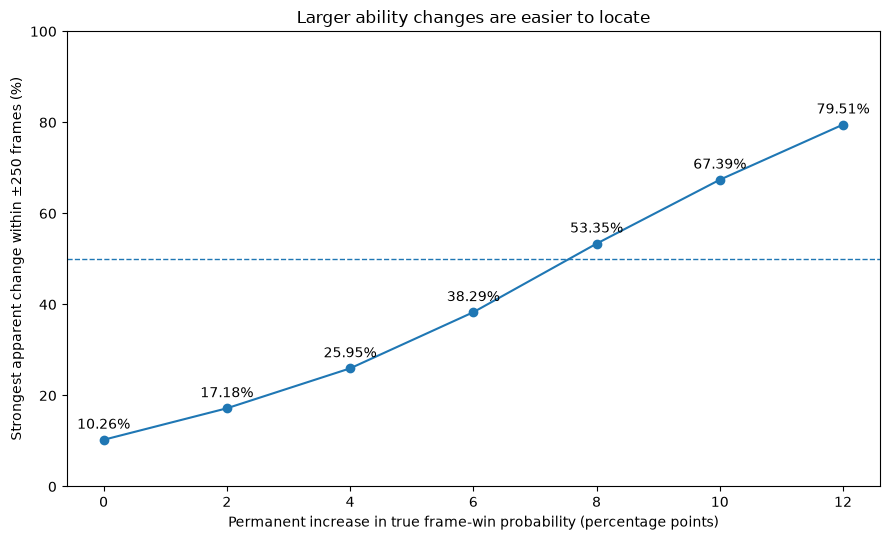

In [12]:
# Plot how often the detector identifies the genuine change region
# as the underlying permanent improvement becomes larger.
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    localisation_summary["change_pp"],
    localisation_summary["localisation_pct"],
    marker="o",
)

# Label each point so the exact simulation result remains visible
# rather than requiring the reader to estimate it from the axis.
for _, row in localisation_summary.iterrows():
    ax.annotate(
        f"{row['localisation_pct']:.2f}%",
        (
            row["change_pp"],
            row["localisation_pct"],
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

# Mark 50% as a useful visual reference:
# above this line, the detector finds the correct ±250-frame region
# in more than half of simulated careers.
ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Larger ability changes are easier to locate"
)
ax.set_xlabel(
    "Permanent increase in true frame-win probability (percentage points)"
)
ax.set_ylabel(
    "Strongest apparent change within ±250 frames (%)"
)

ax.set_xticks(
    localisation_summary["change_pp"]
)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Localisation improves smoothly rather than suddenly

The relationship is not all-or-nothing.

As the genuine permanent improvement becomes larger, the probability of locating it rises steadily.

There is no sharp point at which the detector suddenly becomes reliable.

Instead, each increase in signal strength improves the odds that the real change will dominate the random peaks elsewhere in the career.

The original Study 15 case — a **58% → 64%** improvement — is particularly revealing.

A six-percentage-point increase is large enough to make the true region substantially more detectable than random chance, but not large enough to make it the strongest-looking region in most careers.

The first tested condition to cross the 50% localisation line is:

**58% → 66%**

At that point, the detector identifies a location within ±250 frames of the true change in **53.35%** of careers.

Increasing the change further produces much stronger localisation:

- **58% → 68%:** 67.39%;
- **58% → 70%:** 79.51%.

So Study 15 did not reveal a fixed failure rate inherent to the search procedure.

It revealed one point on a broader signal-strength curve.

> **The stronger the genuine change, the more often it rises above the random alternatives created by searching the rest of the career.**

But even a very large change does not guarantee correct localisation.

At +12 percentage points, the detector still selects a point more than 250 frames away from the genuine change in about one career in five.

Noise has not disappeared.

The real signal has simply become much harder for noise to beat.

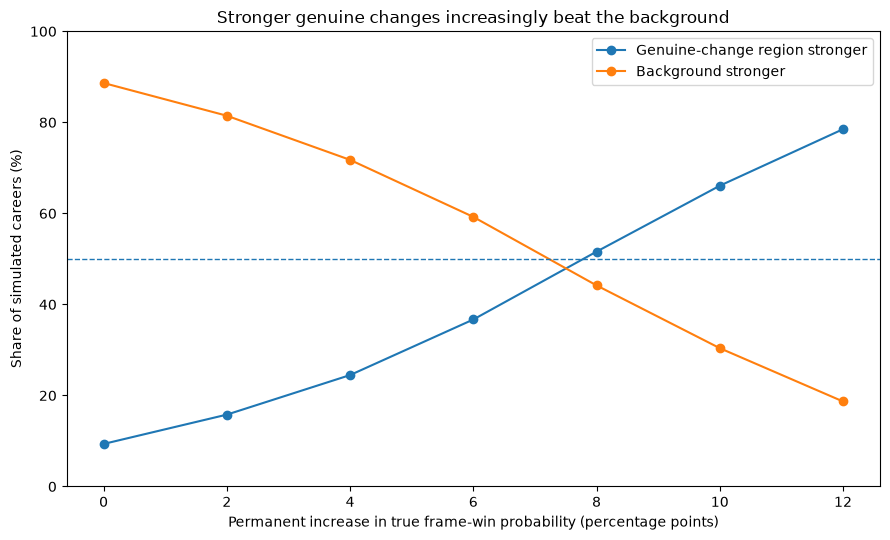

In [13]:
# Plot the direct competition between the genuine-change region
# and the strongest random peak elsewhere in the career.
fig, ax = plt.subplots(figsize=(9, 5.5))

# Probability that the strongest contrast near the true change
# is strictly larger than the strongest background contrast.
ax.plot(
    signal_background_summary["change_pp"],
    signal_background_summary["signal_stronger_rate"],
    marker="o",
    label="Genuine-change region stronger",
)

# Probability that some location elsewhere in the career
# produces a strictly larger apparent improvement.
ax.plot(
    signal_background_summary["change_pp"],
    signal_background_summary["background_stronger_rate"],
    marker="o",
    label="Background stronger",
)

# Mark 50% as a useful reference for which side wins
# in the majority of simulated careers.
ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Stronger genuine changes increasingly beat the background"
)
ax.set_xlabel(
    "Permanent increase in true frame-win probability (percentage points)"
)
ax.set_ylabel(
    "Share of simulated careers (%)"
)

ax.set_xticks(
    signal_background_summary["change_pp"]
)
ax.set_ylim(0, 100)

ax.legend()

plt.tight_layout()
plt.show()

## The competition changes sides

This figure shows the mechanism behind the localisation results more directly.

For small genuine changes, the background still has the advantage.

At +2, +4 and +6 percentage points, the strongest random peak elsewhere in the career is still more likely to exceed the strongest contrast near the real change.

The balance flips between +6 and +8 percentage points.

At **+6 points**:

- genuine-change region stronger: **36.69%**;
- background stronger: **59.23%**.

At **+8 points**:

- genuine-change region stronger: **51.60%**;
- background stronger: **44.18%**.

From that point onward, the genuine signal increasingly dominates the rest of the career.

At +12 percentage points, the genuine-change region produces the stronger contrast in **78.50%** of careers, while the background wins only **18.68%**.

This gives us a useful interpretation of the detector.

The background advantage comes from **opportunity**.

There are thousands of candidate locations across the career where random variation can create an apparently dramatic improvement.

The genuine-change region has far fewer opportunities, but it has a real underlying signal.

When the signal is weak, the background's opportunity advantage wins.

When the signal becomes strong enough, the genuine change starts to overcome that advantage.

> **Study 16 is therefore revealing a competition between signal strength and search-space opportunity.**

The detector becomes useful not because the random background disappears, but because the real signal eventually becomes strong enough to beat it.

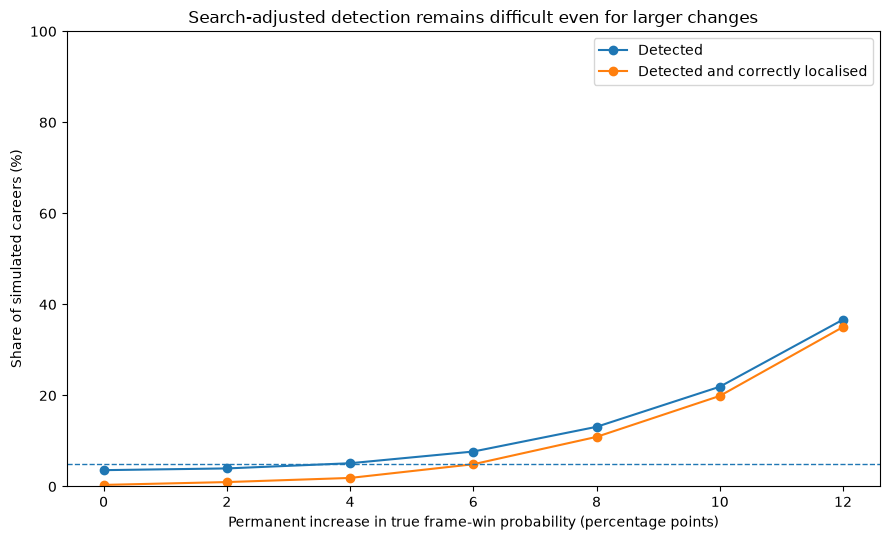

In [14]:
# Plot how often each true change size produces evidence strong enough
# to clear the whole-career false-alarm threshold.
fig, ax = plt.subplots(figsize=(9, 5.5))

# Share of careers whose strongest apparent improvement reaches
# the +41-win search-adjusted detection threshold.
ax.plot(
    detection_summary["change_pp"],
    detection_summary["detection_rate"],
    marker="o",
    label="Detected",
)

# Share of careers that both clear the threshold and place the selected
# location within ±250 frames of the genuine change.
ax.plot(
    detection_summary["change_pp"],
    detection_summary["detected_and_localised_rate"],
    marker="o",
    label="Detected and correctly localised",
)

# Mark the 5% level as a useful reference for the false-alarm target
# used when deriving the whole-career threshold.
ax.axhline(
    5,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Search-adjusted detection remains difficult even for larger changes"
)
ax.set_xlabel(
    "Permanent increase in true frame-win probability (percentage points)"
)
ax.set_ylabel(
    "Share of simulated careers (%)"
)

ax.set_xticks(
    detection_summary["change_pp"]
)
ax.set_ylim(0, 100)

ax.legend()

plt.tight_layout()
plt.show()

## Statistical confidence is harder to achieve than approximate localisation

The search-adjusted threshold imposes a much stricter requirement than simply asking whether the detector points near the true change.

A career counts as detected only if its strongest apparent improvement reaches at least:

**+41 wins**

That threshold was chosen from the no-change simulations so that fewer than 5% of completely stable careers would be falsely flagged.

The consequence is a substantial loss of sensitivity.

For the original **58% → 64%** change:

- localisation within ±250 frames: **38.29%**;
- search-adjusted detection: **7.68%**;
- detection and correct localisation: **4.89%**.

The same gap remains even for much stronger changes.

For **58% → 70%**:

- localisation within ±250 frames: **79.51%**;
- search-adjusted detection: **36.67%**;
- detection and correct localisation: **35.04%**.

So a strong genuine change may frequently leave enough structure for the detector to point toward the correct part of the career without producing an extreme enough contrast to justify a formal whole-career detection.

That distinction matters.

Finding a plausible location and obtaining strong statistical evidence are not the same task.

As the genuine change becomes larger, however, the two detection lines move increasingly close together.

At +12 percentage points, **35.04%** of all careers are both detected and correctly localised, compared with a total detection rate of **36.67%**.

In other words, when a change this large clears the conservative threshold, the detected location is almost always meaningful.

> **Controlling false discoveries makes genuine changes difficult to declare, but stronger signals make the detections that survive increasingly reliable.**

This is the same trade-off seen in Study 15, now revealed as a systematic function of signal strength rather than a peculiarity of one 58% → 64% example.

In [15]:
# Estimate the change size associated with selected localisation targets.
#
# We use simple linear interpolation between the simulated change sizes.
# This is descriptive rather than a new statistical model: it tells us
# approximately where the observed simulation curve crosses each target.
def interpolate_change_size(target_localisation):
    """
    Estimate the percentage-point ability change needed to reach a
    specified localisation rate, using the simulated Study 16 results.
    """

    change_sizes = localisation_summary["change_pp"].to_numpy()
    localisation_rates = localisation_summary["localisation_pct"].to_numpy()

    # Do not extrapolate beyond the range actually covered by the study.
    if (
        target_localisation < localisation_rates.min()
        or target_localisation > localisation_rates.max()
    ):
        return np.nan

    return np.interp(
        target_localisation,
        localisation_rates,
        change_sizes,
    )


# Examine useful landmarks on the localisation curve.
localisation_targets = [25, 50, 75, 90]

for target in localisation_targets:
    estimated_change = interpolate_change_size(target)

    if np.isnan(estimated_change):
        print(
            f"{target}% localisation: "
            f"not reached within the tested 0–12 pp range"
        )
    else:
        print(
            f"{target}% localisation: "
            f"approximately +{estimated_change:.2f} percentage points"
        )

25% localisation: approximately +3.78 percentage points
50% localisation: approximately +7.56 percentage points
75% localisation: approximately +11.26 percentage points
90% localisation: not reached within the tested 0–12 pp range


## How large does the change need to be?

The simulation curve also lets us estimate the approximate change size associated with several localisation targets.

Using simple linear interpolation between the tested conditions:

- **25% localisation** requires roughly a **+3.78 percentage-point** improvement;
- **50% localisation** requires roughly **+7.56 percentage points**;
- **75% localisation** requires roughly **+11.26 percentage points**;
- **90% localisation** is **not reached anywhere within the tested 0–12 percentage-point range**.

These values should not be treated as exact thresholds.

We simulated only seven discrete change sizes, and the interpolation simply describes where the observed curve crosses the chosen target levels.

But they give a useful sense of scale.

A permanent ability increase of around six percentage points — the Study 15 example — is not especially close to reliable localisation under this detector.

The 50% point is reached only at roughly **7.5–8 percentage points**.

To reach around 75% localisation, the true change needs to be on the order of **11 percentage points**.

And even the largest improvement tested, **58% → 70%**, does not produce 90% localisation.

That is a demanding standard.

It means that under this noisy whole-career search:

> **A change can be statistically meaningful without being large enough to make its location consistently obvious.**

This is an important qualification to the idea of simply “looking for where a player's ability changed”.

Unless the underlying shift is substantial, the strongest-looking break in the observed results may still be displaced hundreds of frames from the real change.

## Conclusion

Study 15 showed that a genuine **58% → 64%** ability change could leave a detectable footprint while still being difficult to locate reliably.

Study 16 explains why.

We kept the career, change point, window size and whole-career detector fixed and varied only the size of the permanent improvement.

The result is a clear signal-strength relationship.

Localisation within ±250 frames increased from:

- **10.26%** with no genuine change;
- to **17.18%** at +2 percentage points;
- **25.95%** at +4;
- **38.29%** at +6;
- **53.35%** at +8;
- **67.39%** at +10;
- **79.51%** at +12.

The genuine-change region also became progressively more capable of beating the strongest random peak elsewhere in the career.

At +6 percentage points, the background was still stronger more often than the genuine-change region:

- genuine-change region stronger: **36.69%**;
- background stronger: **59.23%**.

At +8 percentage points, that relationship reversed:

- genuine-change region stronger: **51.60%**;
- background stronger: **44.18%**.

This identifies the basic mechanism.

Searching a long career creates a persistent background of apparently impressive random changes.

Across these experiments, the strongest background contrast remained around **29–30 wins** even as the genuine change became larger.

The real signal therefore has to become strong enough to overcome a hurdle created by thousands of opportunities for random variation.

For the original **58% → 64%** change, it usually was not.

For larger changes, it increasingly was.

The search-adjusted detection results make the standard even tougher.

Using the **+41-win** whole-career threshold derived from the no-change control:

- +6 percentage points was detected in only **7.68%** of careers;
- +8 in **13.11%**;
- +10 in **21.92%**;
- +12 in **36.67%**.

But stronger signals made those detections increasingly trustworthy.

Among detected careers, the selected location was within ±250 frames of the true change:

- **63.67%** of the time at +6 points;
- **83.14%** at +8;
- **90.78%** at +10;
- **95.55%** at +12.

So Study 15's difficulty was not evidence that the detector was fundamentally hopeless.

It was evidence that a **six-percentage-point improvement is modest relative to the noise and the size of the search space**.

The detector contains useful information.

But useful information is not the same as dependable identification.

The approximate localisation curve reinforces that distinction:

- around **+7.56 percentage points** are needed for 50% localisation;
- around **+11.26 percentage points** for 75%;
- 90% localisation was not reached anywhere in the tested range.

The central result is:

> **Whether a genuine ability change can be found depends strongly on how large the change is relative to the random peaks created by searching the rest of the career.**

And the simplest final line is:

> **The stronger the real change, the harder it becomes for randomness elsewhere to look stronger.**